> **Recorded AWS execution — 20260922-000336.** This notebook preserves the original code and scientific outputs. It is an evidence snapshot, not a claim that a data-free clone can rerun the private workspace. Start with [the portfolio overview](00_portfolio_overview.ipynb); see [reproduction instructions](../docs/REPRODUCIBILITY.md) and [current status](../docs/STATUS.md).


# 28 · Exact tracking error budget

## Why stop the previous changes?

Notebook 26 established zero eligible learned daughter pairs. Notebook 27 completed five full-movie comparisons but accepted zero temporal exchanges. Neither changed the score. We now use the **unchanged, saved final predictions**, rather than trying another unmeasured parameter adjustment.

**Official baseline snapshot: 0.947; leader snapshot: 0.974, September 21 at 17:51 UTC.** No fresh leaderboard query is made. The five-movie score is a different evaluation setting.

## Objective

Partition every counted false positive and false negative under the pinned organizer evaluator, distinguish raw detection coverage from postprocessing losses, and identify each missed division using the evaluator’s window-specific matching. This is ground-truth-assisted diagnosis, not inference, training, or an achieved improvement. No prediction graph is changed or written.

In [1]:
from pathlib import Path
import json,warnings
import plotly.graph_objects as go
from IPython.display import Image,display
OUT=Path('/home/sagemaker-user/biohub-cell-tracking-during-development/outputs/competitive_gap_closure/exact_error_budget')
def show(fig,height=580):
    fig.update_layout(width=1040,height=height,margin=dict(l=310,r=60,t=100,b=115))
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore',category=DeprecationWarning)
        png=fig.to_image(format='png',width=1040,height=height,scale=1)
    display(Image(data=png))

r=json.loads((OUT/'result.json').read_text())
assert r['status']=='complete' and len(r['measured_movies'])==5
assert r['prediction_changes']==r['model_fits']==r['network_requests']==r['gpu_inference_calls']==0
print('Frozen local control:',format(r['baseline_summary']['score'],'.9f'))
print('Verified counts:',r['counts'])
print('Movies:',', '.join(r['measured_movies']))
print('New audits:',r['new_movie_audits'],'Reused audits:',r['reused_movies'])


Frozen local control: 0.933045673
Verified counts: {'division_fn': 5, 'division_fp': 1, 'division_tp': 1, 'edge_fn': 112, 'edge_fp': 111, 'edge_tp': 2391}
Movies: 44b6_12dfb391, 6bba_062c8d37, 44b6_267148e4, 6bba_07e24132, 44b6_2a2eff9f
New audits: 5 Reused audits: 0


## Reconciliation comes before interpretation

Original graph checksums and ground-truth metadata/chunks are verified. Counts and scalar metrics must reproduce all five saved controls exactly, within a 1e-10 numeric tolerance. Each counted false-negative edge appears in exactly one category. False-positive labels come from the evaluator’s sparse-annotation validity mask: **an unmatched prediction is not automatically a false positive**.

A missing endpoint means unmatched under the 7 µm one-to-one assignment, not proof that no nucleus exists. The separate raw-to-final coverage comparison is diagnostic; smoothing or competing assignments can change matching even when a prediction ID survives.

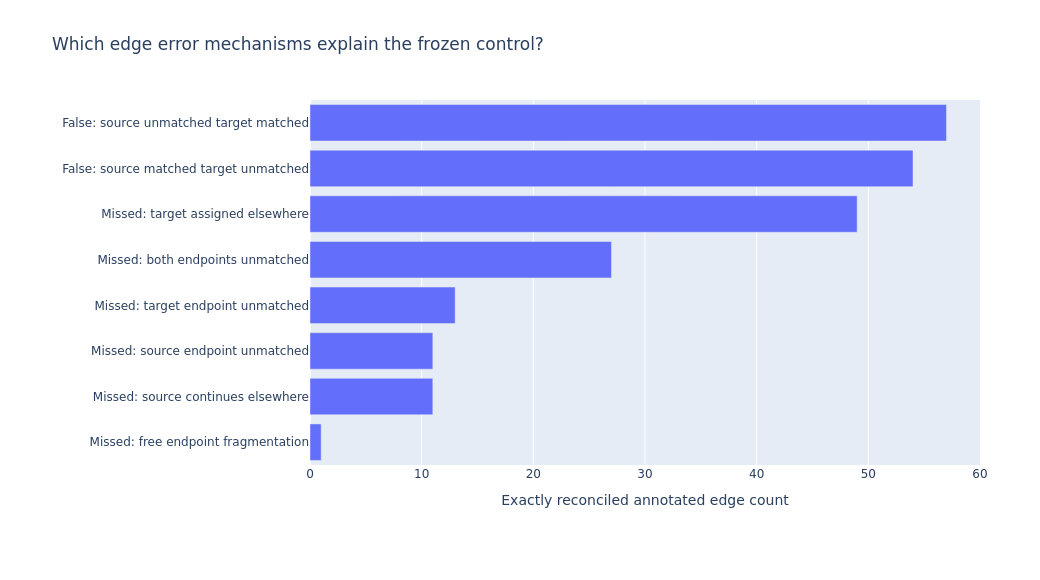

In [2]:
labels=[];values=[]
for group,key in [('Missed','fn_categories'),('False','fp_categories')]:
    for label,value in sorted(r[key].items(),key=lambda x:x[1]):
        labels.append(group+': '+label.replace('_',' '));values.append(value)
fig=go.Figure(go.Bar(y=labels,x=values,orientation='h'))
fig.update_layout(title='Which edge error mechanisms explain the frozen control?',xaxis_title='Exactly reconciled annotated edge count',yaxis_title='')
show(fig,max(580,70*len(labels)))


## Division failures use event-specific matching

The organizer allows a fork one frame early or late and requires two distinct daughter branches. A full-graph edge match must not be substituted for each division’s local parent/daughter matching. Event IDs, supporting predictions, local forks, and rejected topology are saved in the diagnostic records. These few annotated divisions do not establish generalization across embryos.

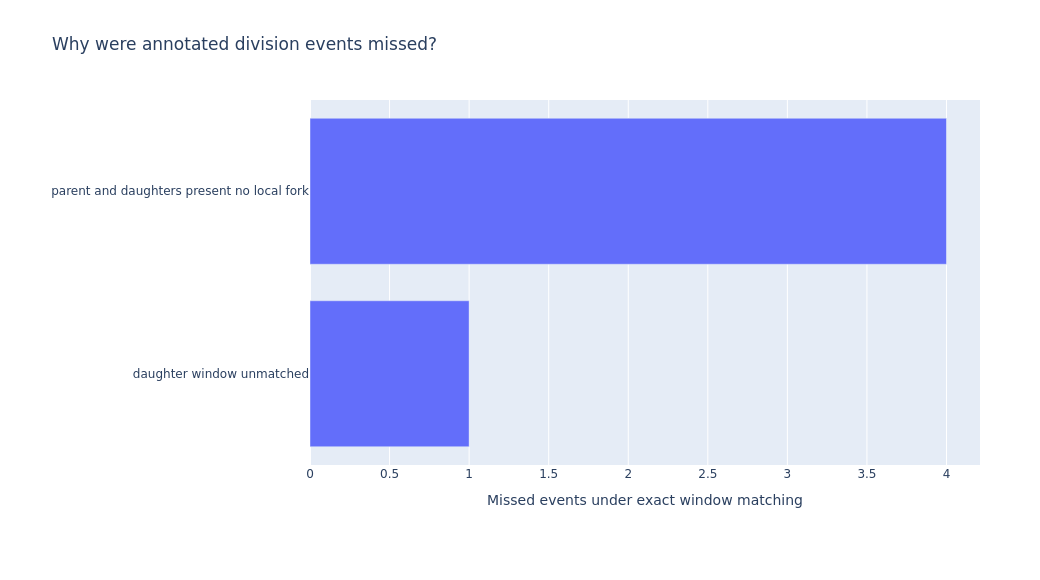

In [3]:
labels=[k.replace('_',' ') for k in r['missed_division_categories']]
vals=list(r['missed_division_categories'].values())
if not labels:labels=['No missed divisions'];vals=[0]
fig=go.Figure(go.Bar(y=labels,x=vals,orientation='h'))
fig.update_layout(title='Why were annotated division events missed?',xaxis_title='Missed events under exact window matching',yaxis_title='')
show(fig)


## Count sensitivities: priorities, not improvements

The following arithmetic asks how the local score would change if one class of counted errors were removed while other counts and node totals stayed fixed. **These use ground truth, are not model results or forecast gains, overlap, and must not be added together.** Recovering missed detections can change node totals and matching; actual improvements may be far smaller or negative. The analysis does not generate an oracle prediction or submission.

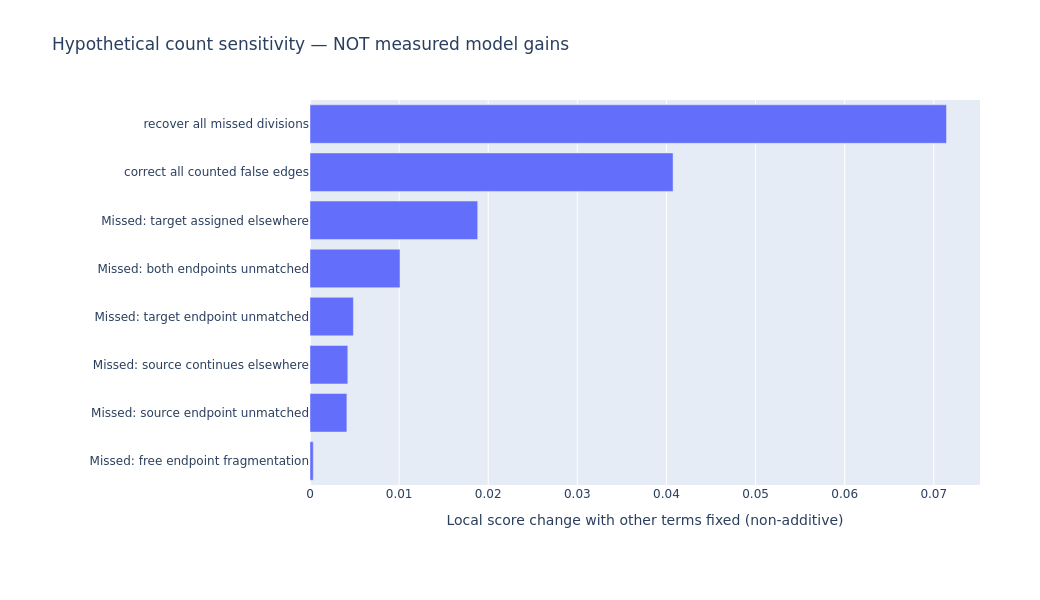

In [4]:
items=list(reversed(r['count_sensitivities']))
labels=[x['scenario'].replace('recover_missed_edges__','Missed: ').replace('_',' ') for x in items]
fig=go.Figure(go.Bar(y=labels,x=[x['delta_from_local_baseline'] for x in items],orientation='h'))
fig.update_layout(title='Hypothetical count sensitivity — NOT measured model gains',xaxis_title='Local score change with other terms fixed (non-additive)',yaxis_title='')
show(fig,max(600,65*len(items)))


## Decision and reproducibility

The next modeling hypothesis must address an error class actually represented here and demonstrate an actionable input before any broader compute. No threshold sweep, data download, training, DeepCenter call, detector call, or submission occurs in this audit. CPU-only graph analysis reuses the five saved reference predictions.

This cohort has been used repeatedly and comprises two embryos; pretrained-model independence is not established. Any later positive screen requires independent validation. Annotation-dependent files stay under diagnostic outputs and are not inference inputs.

Pinned source: RoyerLab kaggle-cell-tracking-competition, commit 075fc5f5a52d11077f9dc2b074644618f26939e2; `metrics.py` and `division_metrics.py` are unchanged.

In [5]:
print('Decision:',r['decision'])
print('No prediction changes; not approved for submission:',r['approved_for_submission'])
print('Leading diagnostic targets:',json.dumps(r['ranked_research_targets'][:3],indent=2))
print('BIOHUB_EXACT_ERROR_BUDGET_NOTEBOOK_COMPLETE')

Decision: design_next_method_from_exact_error_attribution_not_another_blind_threshold_change
No prediction changes; not approved for submission: False
Leading diagnostic targets: [
  {
    "achieved_gain": false,
    "diagnostic": "recover_all_missed_divisions",
    "events": 5,
    "local_count_sensitivity": 0.0714285714285714,
    "next_action": "design_label_free_method_and_independent_validation"
  },
  {
    "achieved_gain": false,
    "diagnostic": "correct_all_counted_false_edges",
    "events": 111,
    "local_count_sensitivity": 0.04074404932676634,
    "next_action": "design_label_free_method_and_independent_validation"
  },
  {
    "achieved_gain": false,
    "diagnostic": "recover_missed_edges__target_assigned_elsewhere",
    "events": 49,
    "local_count_sensitivity": 0.018821798476687523,
    "next_action": "design_label_free_method_and_independent_validation"
  }
]
BIOHUB_EXACT_ERROR_BUDGET_NOTEBOOK_COMPLETE
